## 🎮 Cookie Cats A/B Test Analysis

### Project Overview

У мобільній грі Cookie Cats користувачі стикаються з воротами (gates), які обмежують прогрес та змушують чекати перед переходом на наступні рівні.

Продуктова команда вирішила перевірити, чи вплине перенесення воріт з 30-го рівня на 40-й на довгострокове утримання користувачів.

Мета дослідження - визначити, чи покращує нова версія гри показник утримання користувачів через 7 днів після встановлення.

### Бізнес питання

Чи призводить перенесення воріт із 30-го на 40-й рівень до покращення 7-day retention?

## 1. Sample Size Estimation

Перед початком експерименту було оцінено необхідний розмір вибірки.

Вхідні параметри:

- базове утримання: 19%
- мінімально значущий ефект: +1%
- α = 0.05
- Power = 80%

In [1]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import statsmodels.stats.api as sms
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from math import ceil

%matplotlib inline

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
effect_size = sms.proportion_effectsize(0.20, 0.19)

required_n = sms.NormalIndPower().solve_power(
    effect_size,
    power=0.8,
    alpha=0.05,
    ratio=1
)

required_n = ceil(required_n)

print("Користувачів у кожній групі:", required_n)
print("Користувачів сумарно:", required_n * 2)

Користувачів у кожній групі: 24638
Користувачів сумарно: 49276


In [5]:
df = pd.read_csv('/content/drive/MyDrive/Data/cookie_cats.csv')
df.head()

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


Обчислюю середній показник retention_7 для кожної версії гри

In [6]:
retention_by_version = df.groupby("version")["retention_7"].mean()
print(retention_by_version)

version
gate_30    0.190201
gate_40    0.182000
Name: retention_7, dtype: float64


Перевіряю, чи впливає переміщення воріт з 30-го рівня на 40-й на показник утримання користувачів через 7 днів після встановлення гри (retention_7).

Припускаю, що версія gate_40 може забезпечувати краще утримання користувачів, ніж gate_30, тому формулюємо гіпотези таким чином:

H0: p30 = p40
	​

Ha: p30 < p40

Ми також встановимо рівень значущості 95%

𝛼=0.05
	​


In [7]:
control = df[df["version"] == "gate_30"]["retention_7"]
treatment = df[df["version"] == "gate_40"]["retention_7"]

count = [
    control.sum(),
    treatment.sum()
]

nobs = [
    len(control),
    len(treatment)
]

# z-test
stat, pval = sms.proportions_ztest(count, nobs, alternative="smaller")

# Довірчі інтервали
confint_control = sms.proportion_confint(count[0], nobs[0], alpha=0.05, method="normal")
confint_treatment = sms.proportion_confint(count[1], nobs[1], alpha=0.05, method="normal")

print(f"Z statistic = {stat:.3f}")
print(f"p-value = {pval:.4f}")
print(f"Довірчий інтервал 95% для групи control: [{confint_control[0]:.4f}, {confint_control[1]:.4f}]")
print(f"Довірчий інтервал 95% для групи treatment: [{confint_treatment[0]:.4f}, {confint_treatment[1]:.4f}]")

Z statistic = 3.164
p-value = 0.9992
Довірчий інтервал 95% для групи control: [0.1866, 0.1938]
Довірчий інтервал 95% для групи treatment: [0.1785, 0.1855]


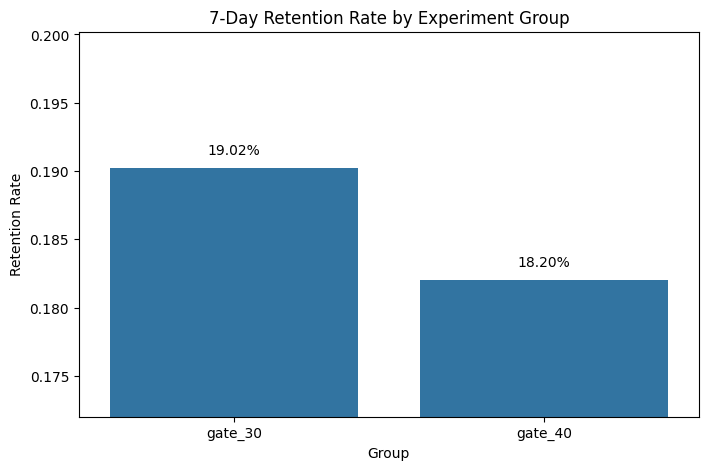

In [8]:
retention_rates = (
    df.groupby("version")["retention_7"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=retention_rates,
    x="version",
    y="retention_7"
)

plt.title("7-Day Retention Rate by Experiment Group")
plt.xlabel("Group")
plt.ylabel("Retention Rate")

plt.ylim(
    retention_rates["retention_7"].min() - 0.01,
    retention_rates["retention_7"].max() + 0.01
)

for idx, row in retention_rates.iterrows():
    plt.text(
        idx,
        row["retention_7"] + 0.001,
        f"{row['retention_7']:.2%}",
        ha="center"
    )

plt.show()

**Висновки**

Перевіряла гіпотезу про те, що версія gate_40 забезпечує краще утримання користувачів через 7 днів після встановлення гри.

Оскільки p-value = 0.9992, що значно перевищує рівень значущості 0.05, ми не маємо підстав відхиляти нульову гіпотезу. Отже, отримані дані не підтверджують припущення про те, що версія gate_40 покращує показник retention_7.

Довірчі інтервали показують, що утримання користувачів є вищим у версії gate_30.

Довірчі інтервали не перетинаються, що свідчить про наявність помітної різниці між версіями гри. Оскільки інтервал для gate_30 повністю розташований вище за інтервал gate_40, це вказує на те, що версія з воротами на 30 рівні демонструє краще утримання користувачів через 7 днів.

## Chi-Square Test

Для додаткової перевірки було виконано χ²-тест незалежності.


Гіпотези для тесту χ²:

H0: версія гри та утримання користувача на 7 день є незалежними.

Ha: між версією гри та утриманням користувача на 7 день існує залежність.

In [9]:
# Формуємо таблицю спряженості

table = pd.crosstab(df["version"], df["retention_7"])
print(table)

retention_7  False  True 
version                  
gate_30      36198   8502
gate_40      37210   8279


In [10]:
# Виконуємо χ²-тест

chi2, p, dof, expected = stats.chi2_contingency(table)

print(f"χ² = {chi2:.3f}")
print(f"p-value = {p:.5f}")
print(f"Ступені свободи = {dof}")

print("Очікувані частоти:\n", expected)

χ² = 9.959
p-value = 0.00160
Ступені свободи = 1
Очікувані частоти:
 [[36382.90257127  8317.09742873]
 [37025.09742873  8463.90257127]]


**Висновки**

Оскільки p-value = 0.00160, що є меншим за рівень значущості 0.05, ми відхиляємо нульову гіпотезу.

Отже, між версією гри та утриманням користувачів через 7 днів після встановлення існує статистично значуща залежність. Це означає, що зміна розташування воріт впливає на поведінку користувачів і на показник retention_7.

### Рекомендації

На основі проведеного аналізу не рекомендується впроваджувати зміну розташування воріт на 40-й рівень.

Контрольна версія (gate_30):

- забезпечує кращий retention;
- не поступається експериментальній версії;
- має більше статистичних підстав залишатися основним варіантом продукту.